In [1]:
import json
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
accuracy_score,
f1_score,
classification_report,
confusion_matrix
)

In [2]:
# Load the processed data
DATA_PATH = Path("../data/processed/crop_recommendation_clean.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Split features and target

target_col = "label"

X = df.drop(columns=target_col)
y = df[target_col]

X.shape, y.shape

((2200, 7), (2200,))

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

((1760, 7), (440, 7))

In [5]:
# Define cross-validation strategy

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
rf_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500, 700],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best random Forest score:", rf_search.best_score_)
print("Best Random Forest parameters:")
rf_search.best_params_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best random Forest score: 0.9948656822973355
Best Random Forest parameters:


{'model__n_estimators': 200,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 1,
 'model__max_features': 'sqrt',
 'model__max_depth': 30,
 'model__bootstrap': False}

In [10]:
et_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", ExtraTreesClassifier(random_state=42))
    ]
)

et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500, 700],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False]
}

et_search = RandomizedSearchCV(
    estimator=et_pipeline,
    param_distributions=et_param_dist,
    n_iter=40,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1

)

et_search.fit(X_train, y_train)

print("Best Extra Trees score:", et_search.best_score_)
print("Best Extra Trees parameters:")
et_search.best_params_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Extra Trees score: 0.9948713284300658
Best Extra Trees parameters:


{'model__n_estimators': 200,
 'model__min_samples_split': 10,
 'model__min_samples_leaf': 1,
 'model__max_features': 'sqrt',
 'model__max_depth': 30,
 'model__bootstrap': True}

In [11]:
tuning_results = pd.DataFrame({
    "model": ["Random Forest", "Extra Trees"],
    "best_cv_macro_f1": [
        rf_search.best_score_,
        et_search.best_score_
    ],
    "best_params_": [
        rf_search.best_params_,
        et_search.best_params_
    ]
})

tuning_results.sort_values("best_cv_macro_f1", ascending = False)

,model,best_cv_macro_f1,best_params_
1,Extra Trees,0.994871,"{'model__n_estimators': 200, 'model__min_sampl..."
0,Random Forest,0.994866,"{'model__n_estimators': 200, 'model__min_sampl..."


In [12]:
if rf_search.best_score_ >= et_search.best_score_:
    best_tuned_model_name = "Random Forest"
    best_tuned_model = rf_search.best_estimator_
    best_tuned_params = rf_search.best_params_
    best_tuned_cv_score = rf_search.best_score_
else:
    best_tuned_model_name = "Extra Trees"
    best_tuned_model = et_search.best_estimator_
    best_tuned_params = et_search.best_params_
    best_tuned_cv_score = et_search.best_score_

best_tuned_model_name, best_tuned_cv_score

('Extra Trees', np.float64(0.9948713284300658))

In [13]:
y_pred = best_tuned_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average="macro")
test_weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Best tuned model:", best_tuned_model_name)
print("Test accuracy:", test_accuracy)
print("Test macro F1:", test_macro_f1)
print("Test weighted F1:", test_weighted_f1)

Best tuned model: Extra Trees
Test accuracy: 0.9977272727272727
Test macro F1: 0.997725851384388
Test weighted F1: 0.997725851384388


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

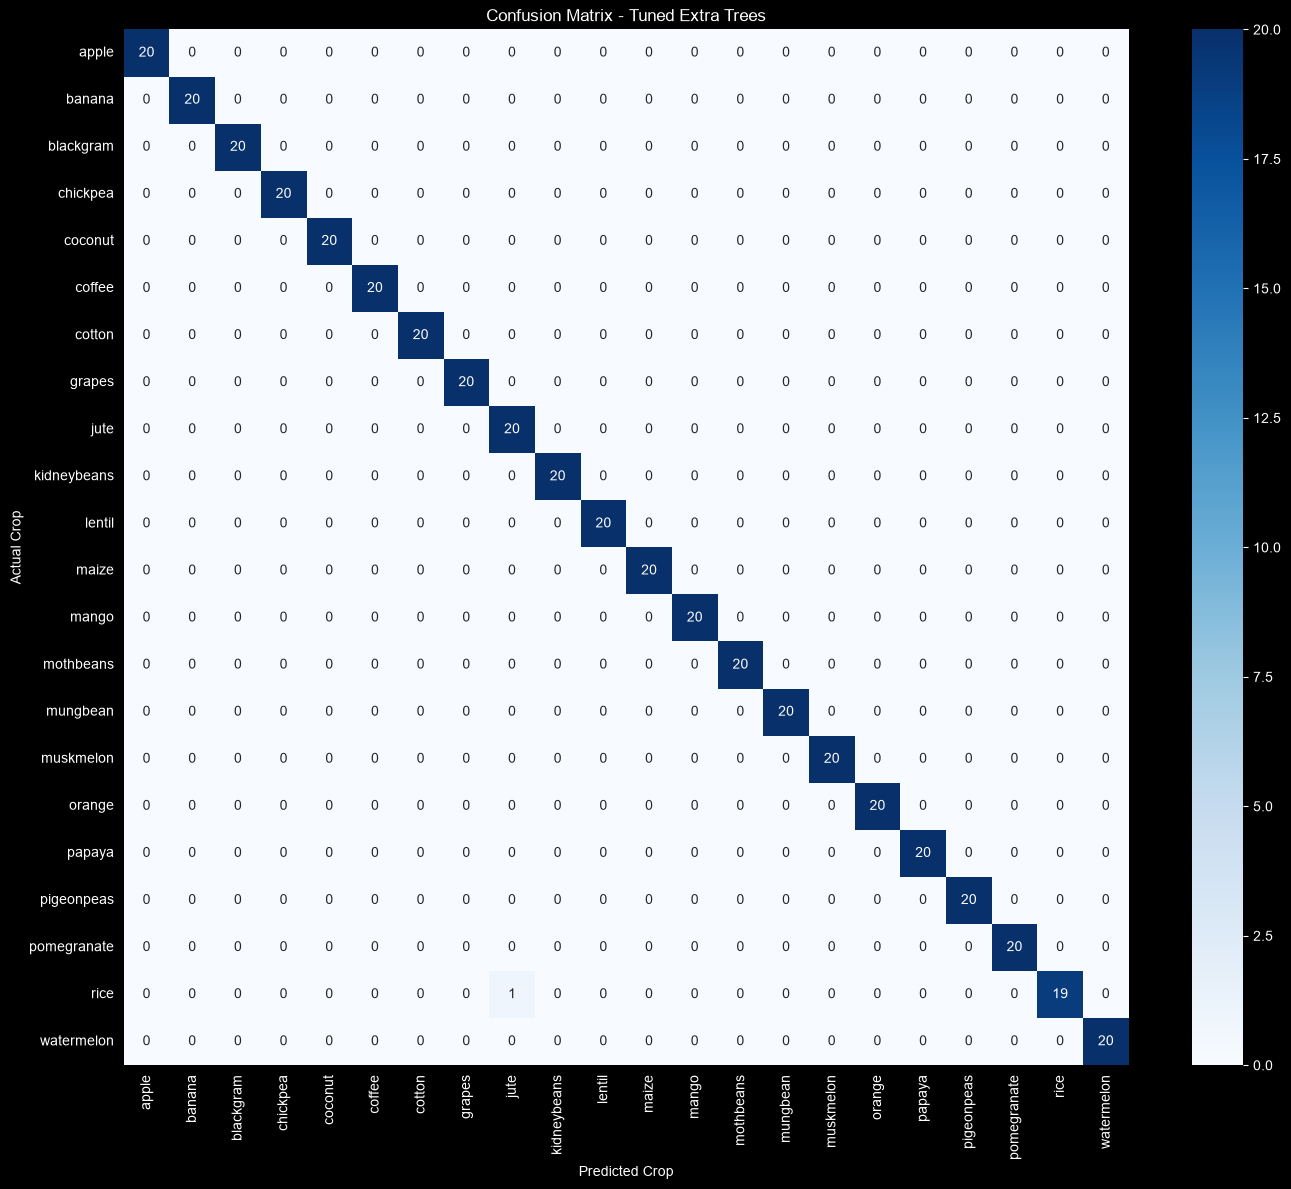

In [15]:
# Create confusion matrix

labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=[14, 12])
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title(f"Confusion Matrix - Tuned {best_tuned_model_name}")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

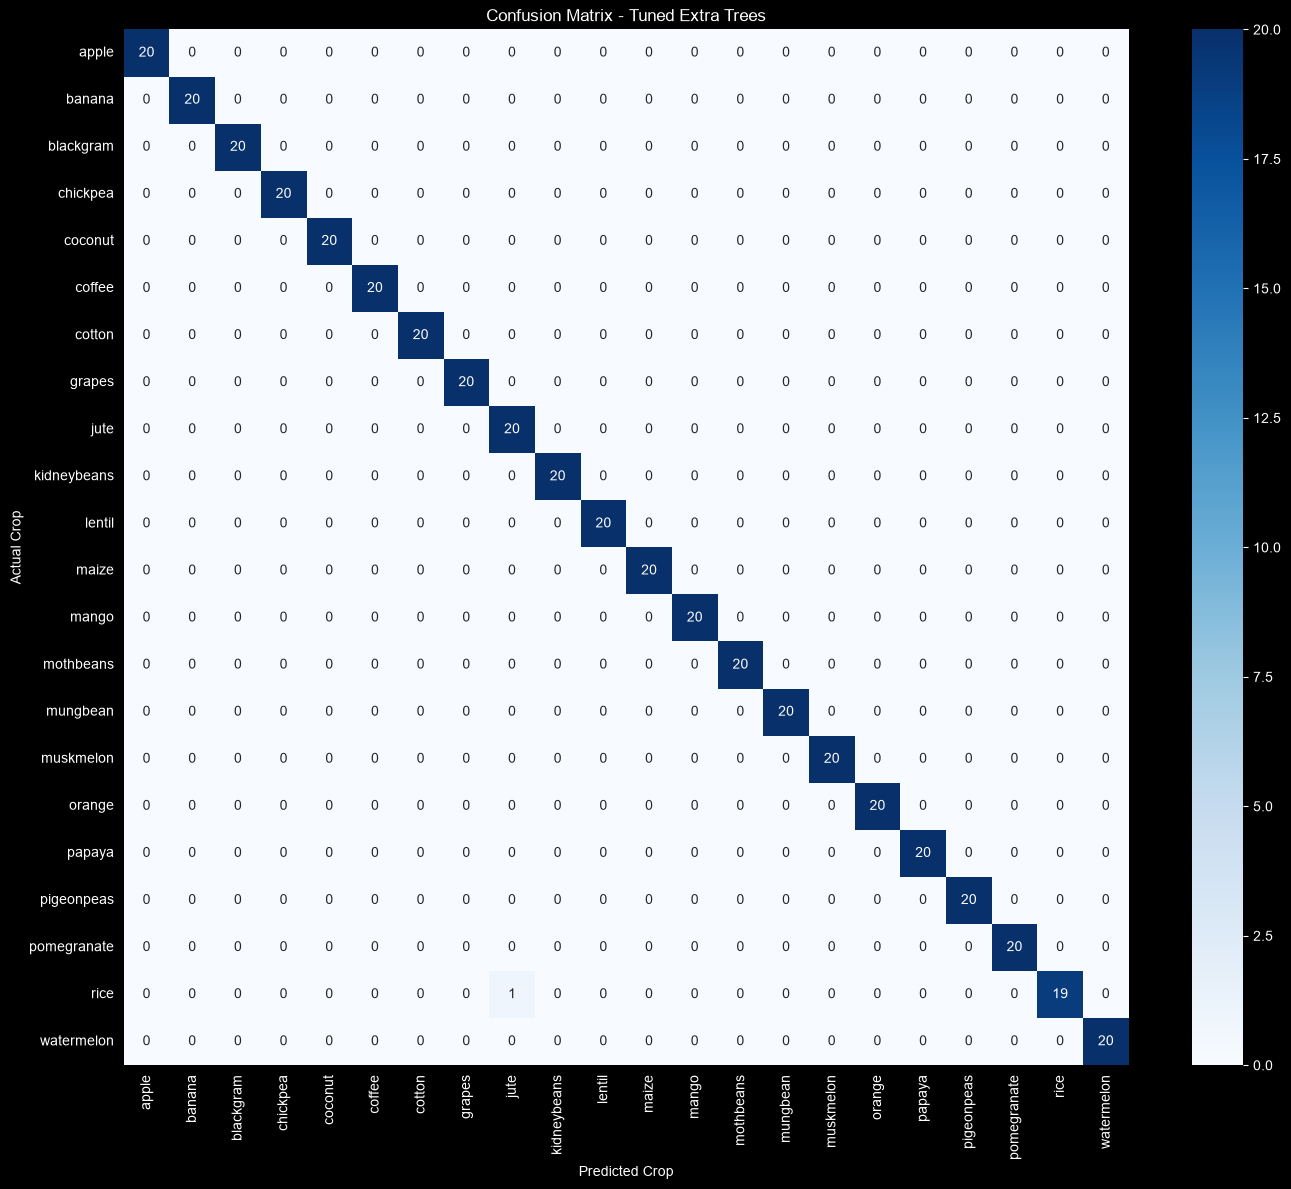

In [16]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title(f"Confusion Matrix - Tuned {best_tuned_model_name}")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix_tuned_model.png", dpi=300)
plt.show()

In [17]:
MODEL_DIR = Path("../models/")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(best_tuned_model, MODEL_DIR / "crop_model_tuned.joblib")

['..\\models\\crop_model_tuned.joblib']

In [18]:
metadata = {
    "model_name": best_tuned_model_name,
    "best_cv_macro_f1": float(best_tuned_cv_score),
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "best_params": best_tuned_params,
    "features": X.columns.tolist(),
    "target": target_col,
    "random_state": 42,
    "test_size": 0.2
}

with open(MODEL_DIR / "tuned_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

metadata

{'model_name': 'Extra Trees',
 'best_cv_macro_f1': 0.9948713284300658,
 'test_accuracy': 0.9977272727272727,
 'test_macro_f1': 0.997725851384388,
 'test_weighted_f1': 0.997725851384388,
 'best_params': {'model__n_estimators': 200,
  'model__min_samples_split': 10,
  'model__min_samples_leaf': 1,
  'model__max_features': 'sqrt',
  'model__max_depth': 30,
  'model__bootstrap': True},
 'features': ['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall'],
 'target': 'label',
 'random_state': 42,
 'test_size': 0.2}

In [19]:
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

tuning_results.to_csv(
    REPORTS_DIR / "hyperparameter_tuning_results.csv",
    index=False
)

## Hyperparameter Tuning Summary

Random Forest and Extra Trees were selected for hyperparameter tuning because they performed strongly during the initial model comparison stage.

RandomizedSearchCV was used to search across different combinations of tree depth, number of estimators, minimum sample split, minimum sample leaf, maximum features, and bootstrap settings.

The tuning process optimized macro-F1 using 5-fold Stratified Cross-Validation.

The tuned model was then evaluated on the held-out test set. The final test performance remained very high, confirming that the full set of soil and climate features contains strong predictive signal for crop classification.

Because the dataset is small, clean, and balanced, the very high model performance should be interpreted carefully. Real-world deployment would require validation with location-specific field data, seasonal patterns, soil type, and actual crop yield outcomes.